Titanic Survival Prediction

In [ ]:
# Descritpion: This program predicts if passenger will survive on Titanic

In [1]:
# Imported Libreries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the Titanic dataset
titanic = sns.load_dataset("titanic")

# Print the first 10 rows of the data
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [3]:
# Count the number of rows and columns of the dataset
titanic.shape

(891, 15)

In [4]:
# Get some statistics
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Get a count of the number of survivors on the titanic
titanic["survived"].value_counts()

,count
survived,
0,549
1,342


<Axes: ylabel='count'>

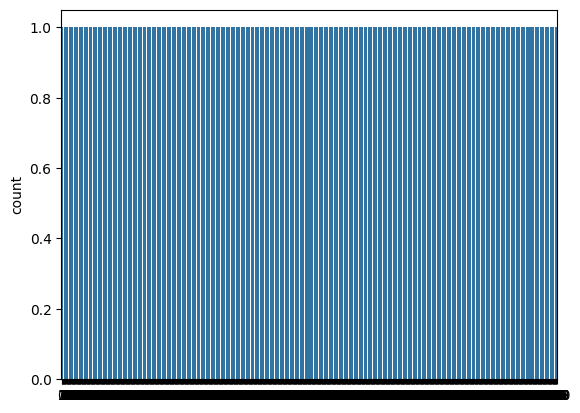

In [13]:
# Visualize the count of the survivors
sns.countplot( titanic['survived'] )

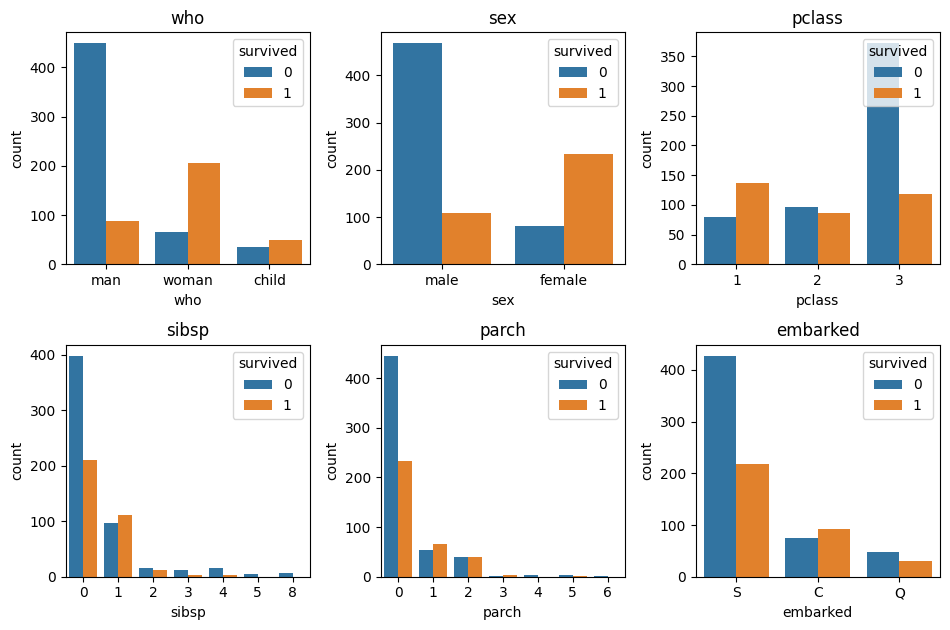

In [15]:
# Visualize the count of survivors for different columns

cols = ['who', 'sex', 'pclass', 'sibsp', 'parch', 'embarked']

n_rows = 2
n_cols = 3

# Create subplot grid
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 3.2))

for r in range(n_rows):
    for c in range(n_cols):

        i = r * n_cols + c  # index for columns
        ax = axs[r][c]      # position of subplot

        sns.countplot(x=titanic[cols[i]], hue=titanic['survived'], ax=ax)

        ax.set_title(cols[i])
        ax.legend(title='survived', loc='upper right')

plt.tight_layout()
plt.show()

In [16]:
# Look at survival rate by sex
titanic.groupby('sex')[['survived']].mean()

,survived
sex,
female,0.742038
male,0.188908


In [17]:
# Look at survival rate by sex and class
titanic.pivot_table('survived', index = 'sex', columns = 'class')

/tmp/ipykernel_5043/1605112072.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index = 'sex', columns = 'class')


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


/tmp/ipykernel_5043/3018362427.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index = 'sex', columns = 'class').plot()


<Axes: xlabel='sex'>

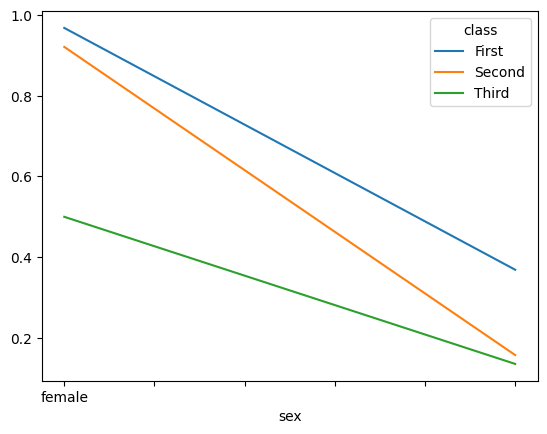

In [18]:
# Look at survival rate by sex and class visually
titanic.pivot_table('survived', index = 'sex', columns = 'class').plot()

<Axes: xlabel='class', ylabel='survived'>

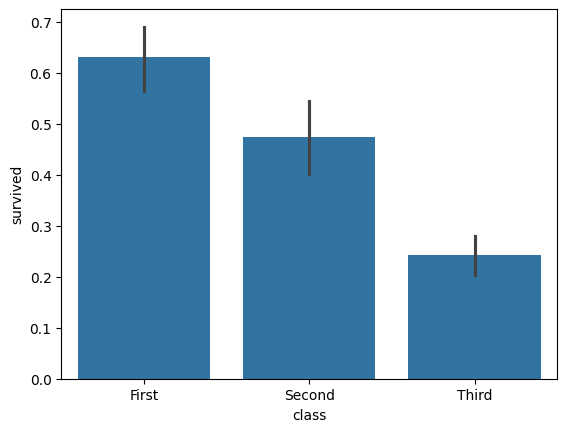

In [19]:
# Plot the survival rate of each class
sns.barplot(x = 'class', y = 'survived', data = titanic)

In [20]:
# Look at survival rate by sex, age and class
age = pd.cut(titanic['age'], [0,18,80])
titanic.pivot_table('survived', ['sex', age], 'class')

/tmp/ipykernel_5043/576396209.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['sex', age], 'class')


class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

<function matplotlib.pyplot.show(close=None, block=None)>

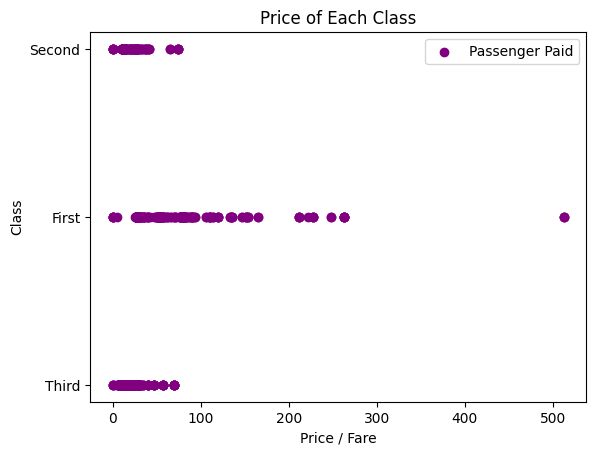

In [21]:
# Plot the prices paid each class
plt.scatter(titanic['fare'], titanic['class'], color = 'purple', label = 'Passenger Paid')
plt.ylabel('Class')
plt.xlabel('Price / Fare')
plt.title('Price of Each Class')
plt.legend()
plt.show

In [22]:
# Count the empty values in each column
titanic.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [23]:
# Look at all of the values of each column & get a count
for val in titanic:
  print(titanic[val].value_counts())
  print()

survived
0    549
1    342
Name: count, dtype: int64

pclass
3    491
1    216
2    184
Name: count, dtype: int64

sex
male      577
female    314
Name: count, dtype: int64

age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

class
Third     491
First     216
Second    184
Name: count, dtype: int64

who
man      537
woman    271
child     83
Name: count, dtype: int64

adult_male
True     537
False    354
Name: count, dt

In [51]:


# Remove the rows with missing values
titanic = titanic.dropna()

In [33]:
# Count the NEW number of rows and columns in the dataset
titanic.shape

(891, 15)

In [35]:
# Look at the data types
titanic.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [52]:
# Print the unique values in the columns
print(titanic['sex'].unique())
print(titanic['embarked'].unique())

[1 0]
[2 0 1 3]


In [53]:
# Look at the data types
titanic.dtypes


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object


In [54]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

# Encode the sex column
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

titanic.iloc[:, 2] = labelencoder.fit_transform(titanic.iloc[:, 2].values)

# Encode the embarked column
titanic.iloc[:, 7] = labelencoder.fit_transform(titanic.iloc[:, 7].values)

In [55]:
# Print encoded values
print(titanic['sex'].unique())
print(titanic['embarked'].unique())

[1 0]
[2 0 1 3]


In [56]:
# Print the unique values in the columns
print(titanic['sex'].unique())
print(titanic['embarked'].unique())

[1 0]
[2 0 1 3]


In [57]:
titanic.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object


In [58]:
# Split the data into independent 'X' and dependent 'Y' variables
X = titanic.iloc[:, 1:8].values
Y = titanic.iloc[:, 0].values

In [60]:
# Split the dataset into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 0
)

In [61]:
# Scale the data
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [62]:
# Create a function with many ML models
def models(X_train, Y_train):
  # Use logistic Regression
  from sklearn.linear_model import LogisticRegression
  log = LogisticRegression(random_state = 0)
  log.fit(X_train, Y_train)

  # Use KNeighbors
  from sklearn.neighbors import KNeighborsClassifier
  knn = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
  knn.fit(X_train, Y_train)

  # Use SVC (Linear kernel)
  from sklearn.svm import SVC
  svc_lin = SVC(kernel = 'linear', random_state = 0)
  svc_lin.fit(X_train, Y_train)

  # Use SVC (RBF kernel)
  from sklearn.svm import SVC
  svc_rbf = SVC(kernel = 'rbf', random_state = 0)
  svc_rbf.fit(X_train, Y_train)

  # Use GaussianNB
  from sklearn.naive_bayes import GaussianNB
  gauss = GaussianNB()
  gauss.fit(X_train, Y_train)

  # Use decision tree
  from sklearn.tree import DecisionTreeClassifier
  tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
  tree.fit(X_train, Y_train)

  #Use the RandomForestClassifier
  from sklearn.ensemble import RandomForestClassifier
  forest = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
  forest.fit(X_train, Y_train)

  # Print the training accuracy for each model
  print('[0]Logistic Regression Training Accuracy:', log.score(X_train, Y_train))
  print('[1]K Neighbors Regression Training Accuracy:', knn.score(X_train, Y_train))
  print('[2]SVC Linear Regression Training Accuracy:', svc_lin.score(X_train, Y_train))
  print('[3]SVC RBF Regression Training Accuracy:', svc_rbf.score(X_train, Y_train))
  print('[4]Gaussian NB Regression Training Accuracy:', gauss.score(X_train, Y_train))
  print('[5]Decision Tree Regression Training Accuracy:', tree.score(X_train, Y_train))
  print('[6]Random Forest Regression Training Accuracy:', forest.score(X_train, Y_train))


  return log, knn, svc_lin, svc_rbf, gauss, tree, forest

In [63]:
# Get and Train all of the models
model = models(X_train, Y_train)

[0]Logistic Regression Training Accuracy: 0.7933450087565674
[1]K Neighbors Regression Training Accuracy: 0.8598949211908932
[2]SVC Linear Regression Training Accuracy: 0.7758318739054291
[3]SVC RBF Regression Training Accuracy: 0.8476357267950964
[4]Gaussian NB Regression Training Accuracy: 0.7933450087565674
[5]Decision Tree Regression Training Accuracy: 0.9877408056042032
[6]Random Forest Regression Training Accuracy: 0.9667250437828371


In [64]:
# Show the confusiom matrix and accuracy for all of the models on the test data
from sklearn.metrics import confusion_matrix

for i in range(len(model)):
  cm = confusion_matrix(Y_test, model[i].predict(X_test))

  # Extract TN, FP, FN, TP
  TN, FP, FN, TP = confusion_matrix(Y_test, model[i].predict(X_test)).ravel()

  test_score = (TP + TN) / (TP + TN + FN + FP)

  print(cm)
  print('Model[{}] Testing Accuracy = "{}"'.format(i, test_score))
  print()

[[67 12]
 [12 52]]
Model[0] Testing Accuracy = "0.8321678321678322"

[[66 13]
 [16 48]]
Model[1] Testing Accuracy = "0.7972027972027972"

[[68 11]
 [18 46]]
Model[2] Testing Accuracy = "0.7972027972027972"

[[73  6]
 [23 41]]
Model[3] Testing Accuracy = "0.7972027972027972"

[[64 15]
 [16 48]]
Model[4] Testing Accuracy = "0.7832167832167832"

[[65 14]
 [13 51]]
Model[5] Testing Accuracy = "0.8111888111888111"

[[67 12]
 [19 45]]
Model[6] Testing Accuracy = "0.7832167832167832"



In [66]:
# Get feature importrance
forest = model[6]
importances = pd.DataFrame({'feature': titanic.iloc[:, 1:8].columns, 'importance': np.round(forest.feature_importances_, 3)})
importances = importances.sort_values('importance', ascending = False).set_index('feature')
importances

,importance
feature,
age,0.317
fare,0.292
sex,0.202
pclass,0.073
sibsp,0.045
parch,0.042
embarked,0.028


<Axes: xlabel='feature'>

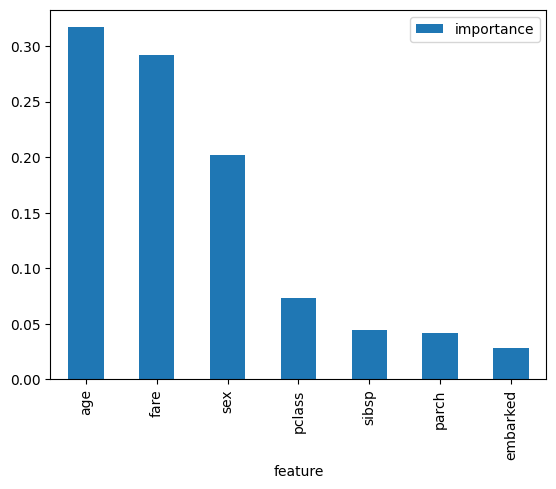

In [67]:
# Visualize the importances
importances.plot.bar()

In [68]:
# Print the prediction of the Random Forest Classifier model
pred = model[6].predict(X_test)
print(pred)

print()

# Print the actual values
print(Y_test)

[1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0 1 0 0 1 1 1
 1 1 0 1 0 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 0 1 1 0 0 1 1 0 1 0 0 0 1 0 1]

[0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1
 1 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1
 1 1 1 0 0 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1 1 1 0 1 1 1 0 1 0 0
 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 1 0 1]


In [70]:
# My survival
my_survival = [[3, 1, 21, 0, 0, 0, 1]]

# Scaling my survial
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
my_survival_scaled = sc.fit_transform(my_survival)

# Print prediction of my survival using Random Forest Classifier
pred = model[6].predict(my_survival_scaled)
print(pred)

if pred == 0:
  print('No way bro! You are dead')
else:
  print('Nice! You survived')

[0]
No way bro! You are dead
